# Task 1 — Material Property Modelling
## EXCAVATE | MatRisk AI | COMPOSIT, IIT Kharagpur

**Objective:** Predict mechanical, thermal, and electronic properties of materials from structural features, and compute a composite Material Quality Index (MQI).

**Dataset:** DS1 — 5,500 materials with structural and physical properties  
**Approach:** Gradient Boosting Regressor / Classifier with domain-informed feature engineering

---

## 1. Imports & Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (r2_score, mean_absolute_error,
                              accuracy_score, roc_auc_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load & Explore Data

In [21]:
# ── adjust path if needed ──
ds1 = pd.read_csv('DS1_material_properties_5500.csv')
ds4 = pd.read_csv('DS4_ mqi_weights.csv')

print(f"DS1 shape: {ds1.shape}")
print(f"\nColumns: {ds1.columns.tolist()}")
print(f"\nMissing values:\n{ds1.isnull().sum()}")
ds1.head()

DS1 shape: (5500, 18)

Columns: ['material_id', 'formula', 'n_elements', 'crystal_system', 'spacegroup_number', 'category', 'formation_energy_per_atom_eV', 'energy_above_hull_eV', 'band_gap_eV', 'is_metal', 'bulk_modulus_GPa', 'shear_modulus_GPa', 'poisson_ratio', 'density_g_cm3', 'nsites', 'volume_A3', 'melting_point_K', 'is_stable']

Missing values:
material_id                     0
formula                         0
n_elements                      0
crystal_system                  0
spacegroup_number               0
category                        0
formation_energy_per_atom_eV    0
energy_above_hull_eV            0
band_gap_eV                     0
is_metal                        0
bulk_modulus_GPa                0
shear_modulus_GPa               0
poisson_ratio                   0
density_g_cm3                   0
nsites                          0
volume_A3                       0
melting_point_K                 0
is_stable                       0
dtype: int64


,material_id,formula,n_elements,crystal_system,spacegroup_number,category,formation_energy_per_atom_eV,energy_above_hull_eV,band_gap_eV,is_metal,bulk_modulus_GPa,shear_modulus_GPa,poisson_ratio,density_g_cm3,nsites,volume_A3,melting_point_K,is_stable
0,mp-121959,Ta3Au3H2,3,hexagonal,185,Chalcogenide,-0.6329,0.0175,1.940,0,26.87,13.47,0.2918,4.343,2,96.38,1142.0,1
1,mp-23248,Al3Rh4W3,3,hexagonal,171,Alloy,-1.2275,0.2124,0.000,1,50.30,33.94,0.2326,6.757,4,365.02,1244.0,0
2,mp-526982,Pd3Te3,2,cubic,227,Metal,0.1265,0.0993,0.000,1,256.03,125.93,0.2849,10.501,4,642.24,1178.0,0
3,mp-984775,Ne4Cd4,2,tetragonal,81,Nitride,-0.4655,0.0534,1.830,0,461.87,233.17,0.2888,1.754,32,820.52,1130.0,0
4,mp-965909,Al4Rh,2,cubic,202,Nitride,-0.6142,0.0501,1.264,0,187.79,148.00,0.1900,3.360,2,87.85,306.0,0


## 3. Exploratory Data Analysis

In [22]:
# ── 3.1  Basic statistics ──
print("=== Dataset Statistics ===")
print(ds1.describe().round(3))

=== Dataset Statistics ===
       n_elements  spacegroup_number  formation_energy_per_atom_eV  \
count    5500.000           5500.000                      5500.000   
mean        2.429            133.610                        -1.596   
std         0.868             76.694                         1.502   
min         1.000              1.000                        -6.500   
25%         2.000             60.000                        -2.539   
50%         2.000            165.000                        -1.265   
75%         3.000            200.000                        -0.481   
max         4.000            230.000                         1.500   

       energy_above_hull_eV  band_gap_eV  is_metal  bulk_modulus_GPa  \
count              5500.000     5500.000  5500.000          5500.000   
mean                  0.058        2.099     0.325           144.516   
std                   0.071        2.518     0.469            84.120   
min                   0.000        0.000     0.000    

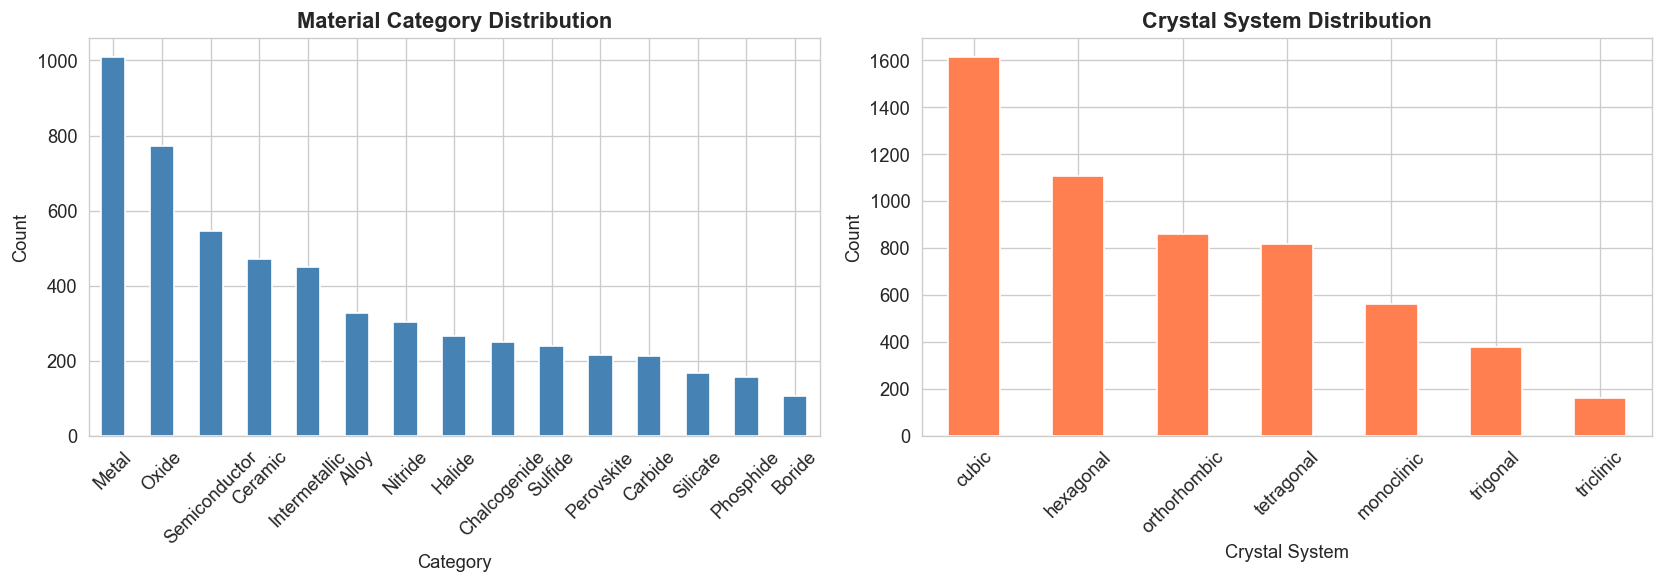

In [23]:
# ── 3.2  Category and crystal system distributions ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ds1['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Material Category Distribution', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

ds1['crystal_system'].value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Crystal System Distribution', fontweight='bold')
axes[1].set_xlabel('Crystal System')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

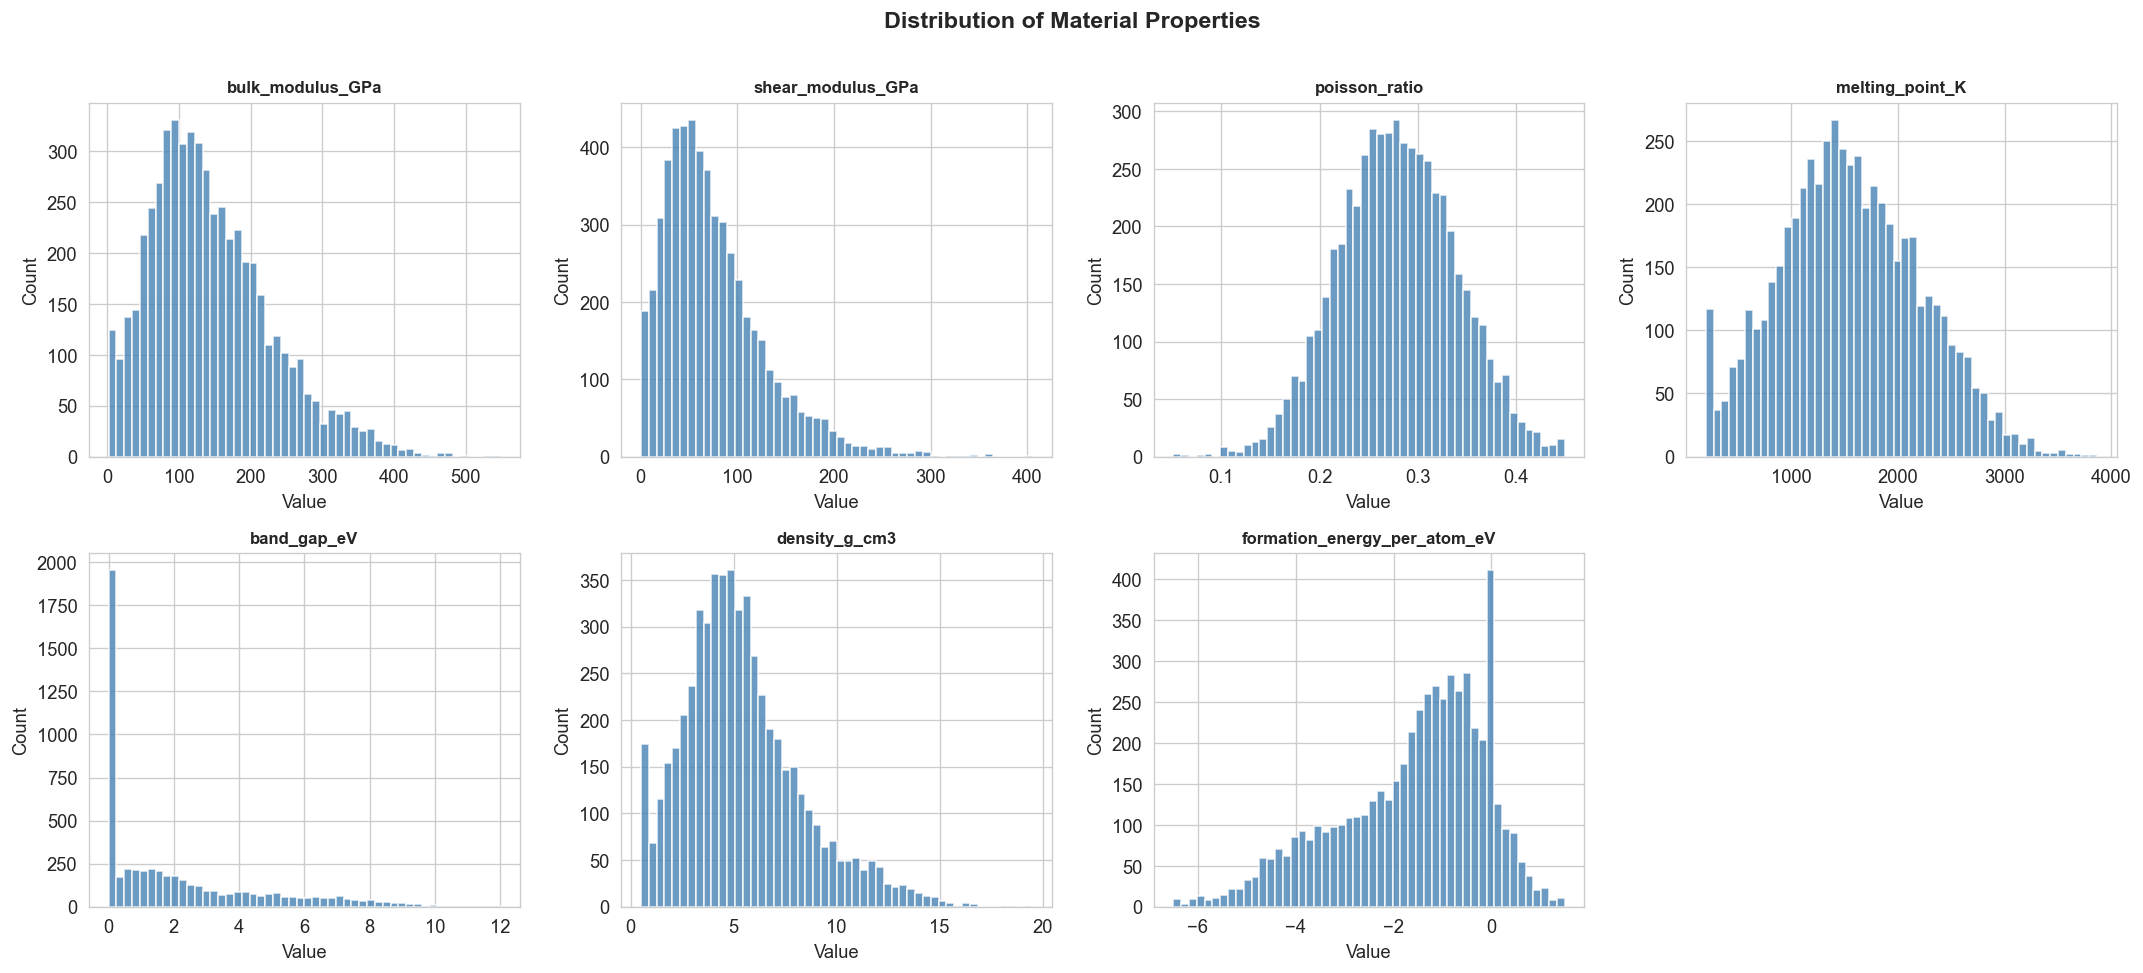

In [24]:
# ── 3.3  Property distributions ──
num_props = ['bulk_modulus_GPa','shear_modulus_GPa','poisson_ratio',
             'melting_point_K','band_gap_eV','density_g_cm3','formation_energy_per_atom_eV']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_props):
    axes[i].hist(ds1[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Distribution of Material Properties', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

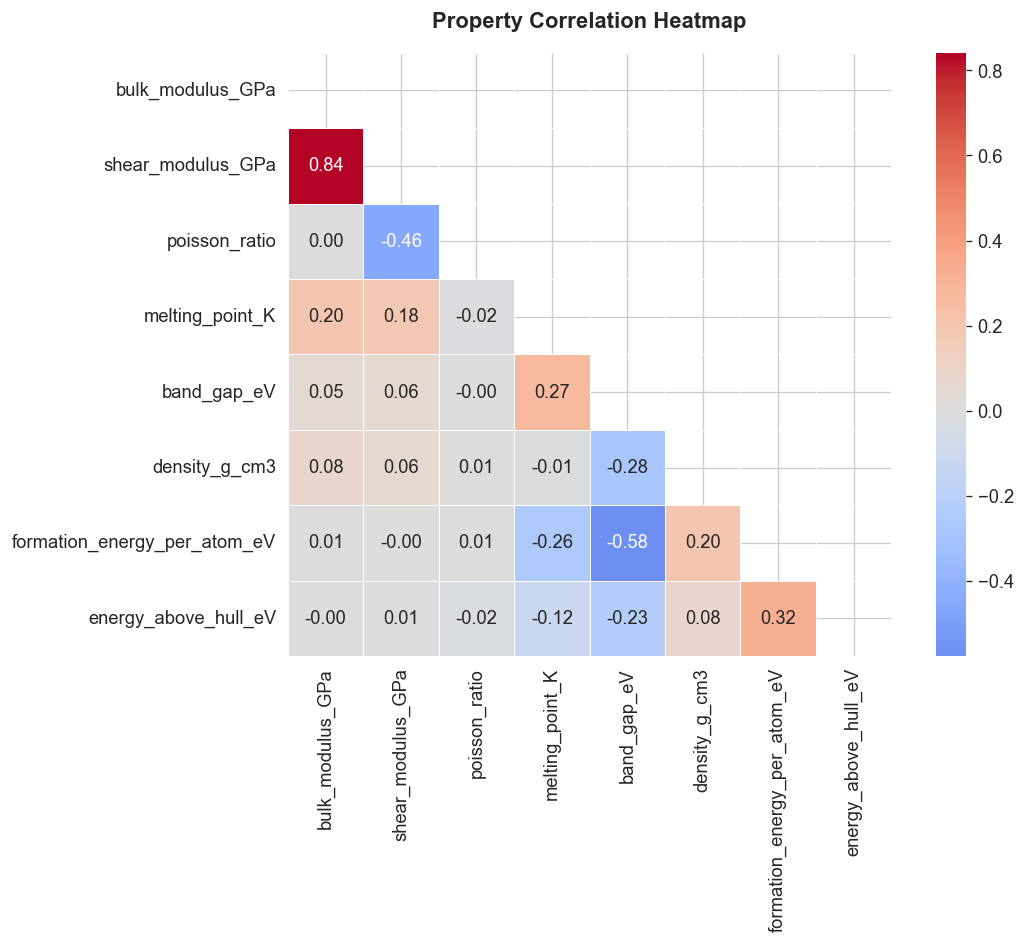

In [25]:
# ── 3.4  Correlation heatmap ──
corr_cols = ['bulk_modulus_GPa','shear_modulus_GPa','poisson_ratio',
             'melting_point_K','band_gap_eV','density_g_cm3',
             'formation_energy_per_atom_eV','energy_above_hull_eV']

plt.figure(figsize=(10, 8))
corr = ds1[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Property Correlation Heatmap', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

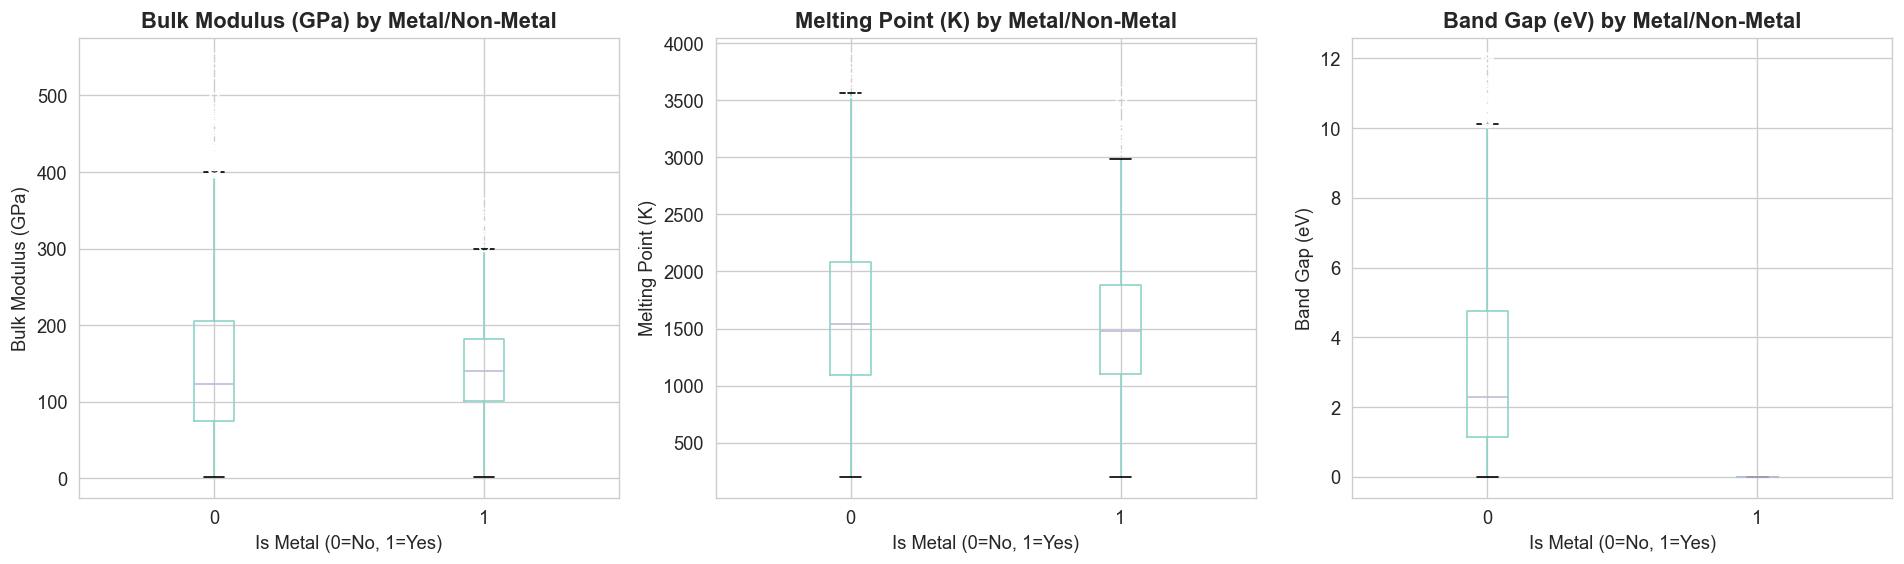

In [26]:
# ── 3.5  Metals vs Non-metals ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
props_box = ['bulk_modulus_GPa', 'melting_point_K', 'band_gap_eV']
labels = ['Bulk Modulus (GPa)', 'Melting Point (K)', 'Band Gap (eV)']

for ax, prop, label in zip(axes, props_box, labels):
    ds1.boxplot(column=prop, by='is_metal', ax=ax)
    ax.set_title(f'{label} by Metal/Non-Metal', fontweight='bold')
    ax.set_xlabel('Is Metal (0=No, 1=Yes)')
    ax.set_ylabel(label)

plt.suptitle('')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [27]:
# ── Label encode categoricals ──
le_crystal = LabelEncoder()
le_cat     = LabelEncoder()
ds1['crystal_enc']  = le_crystal.fit_transform(ds1['crystal_system'])
ds1['category_enc'] = le_cat.fit_transform(ds1['category'])

# ── Domain-informed derived features ──
# Pugh's ratio: K/G > 1.75 => ductile, < 1.75 => brittle
ds1['pughs_ratio']        = ds1['bulk_modulus_GPa'] / (ds1['shear_modulus_GPa'] + 1e-8)

# Elastic anisotropy
ds1['elastic_anisotropy'] = ds1['bulk_modulus_GPa'] - ds1['shear_modulus_GPa']

# Thermal stability proxy: high melting point + low formation energy = stable
ds1['thermal_stability']  = ds1['melting_point_K'] / (np.abs(ds1['formation_energy_per_atom_eV']) + 1e-8)

# Electronic-structural coupling
ds1['electronic_density'] = ds1['band_gap_eV'] * ds1['density_g_cm3']

# Volume per atom site
ds1['vol_per_site']       = ds1['volume_A3'] / ds1['nsites']

print("Engineered features added:")
new_feats = ['pughs_ratio','elastic_anisotropy','thermal_stability','electronic_density','vol_per_site']
print(ds1[new_feats].describe().round(3))

Engineered features added:
       pughs_ratio  elastic_anisotropy  thermal_stability  electronic_density  \
count     5500.000            5500.000       5.500000e+03            5500.000   
mean         2.163              68.883       6.272295e+09               9.368   
std          0.932              49.164       3.245443e+10              12.697   
min          0.758             -70.320       3.498800e+01               0.000   
25%          1.584              33.410       5.838230e+02               0.000   
50%          1.928              58.790       1.097590e+03               4.090   
75%          2.464              93.115       2.468983e+03              13.827   
max         10.594             376.460       3.576000e+11              87.612   

       vol_per_site  
count      5500.000  
mean         65.270  
std          38.701  
min           2.942  
25%          37.834  
50%          58.125  
75%          85.622  
max         308.138  


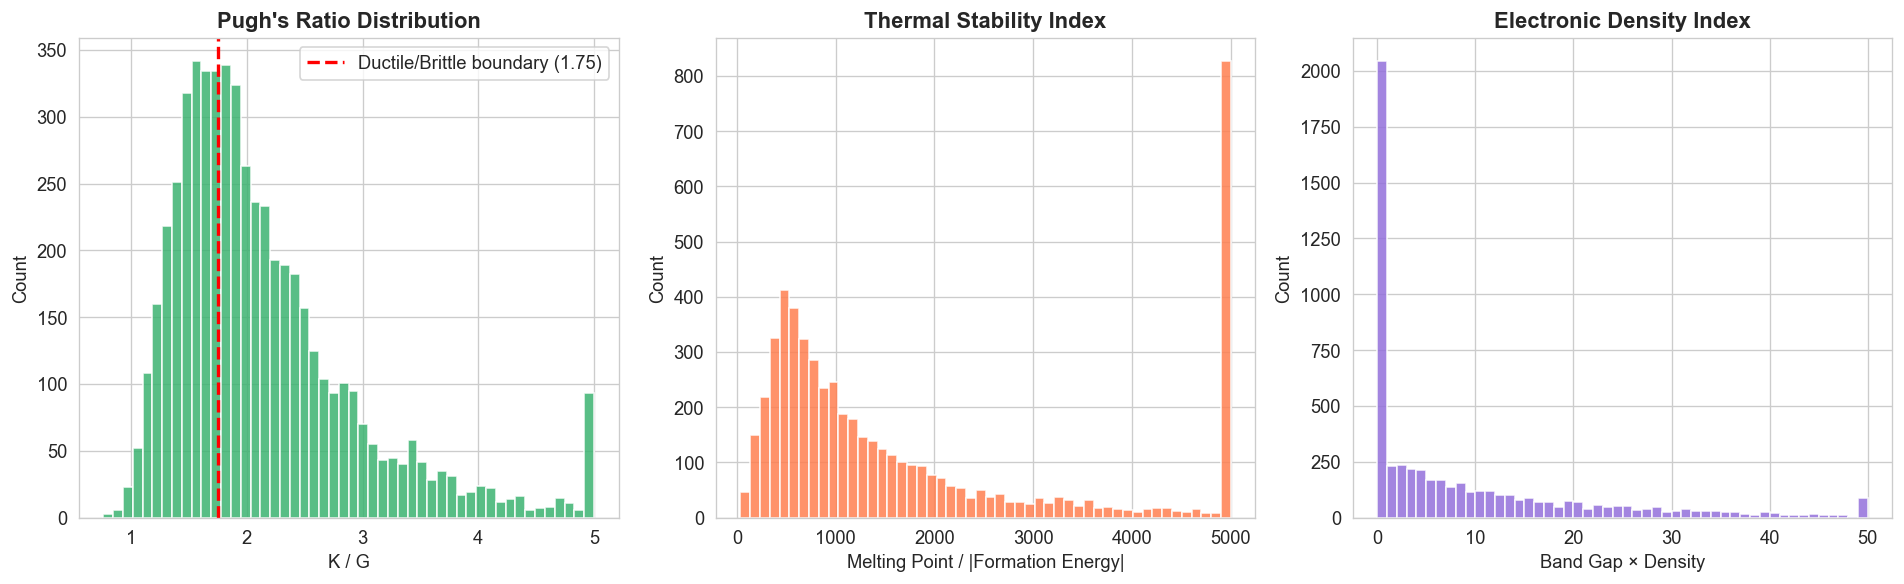

In [28]:
# ── Visualise engineered features ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pugh's ratio
axes[0].hist(ds1['pughs_ratio'].clip(0, 5), bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(1.75, color='red', linestyle='--', linewidth=2, label="Ductile/Brittle boundary (1.75)")
axes[0].set_title("Pugh's Ratio Distribution", fontweight='bold')
axes[0].set_xlabel("K / G")
axes[0].set_ylabel("Count")
axes[0].legend()

# Thermal stability
axes[1].hist(ds1['thermal_stability'].clip(0, 5000), bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title("Thermal Stability Index", fontweight='bold')
axes[1].set_xlabel("Melting Point / |Formation Energy|")
axes[1].set_ylabel("Count")

# Electronic density
axes[2].hist(ds1['electronic_density'].clip(0, 50), bins=50, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[2].set_title("Electronic Density Index", fontweight='bold')
axes[2].set_xlabel("Band Gap × Density")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [29]:
BASE = ['n_elements','spacegroup_number','crystal_enc','category_enc',
        'nsites','volume_A3','vol_per_site',
        'pughs_ratio','elastic_anisotropy','thermal_stability','electronic_density']

SPLIT = int(len(ds1) * 0.8)
print(f"Train size: {SPLIT}  |  Test size: {len(ds1)-SPLIT}")

Train size: 4400  |  Test size: 1100


## 5. Material Quality Index (MQI) Calculation

In [30]:
# ── DS4 weights ──
print(ds4)

MQI_PROPS = {
    'bulk_modulus_GPa':           0.20,
    'shear_modulus_GPa':          0.20,
    'formation_energy_per_atom_eV': 0.20,
    'density_g_cm3':              0.10,
    'melting_point_K':            0.15,
    'band_gap_eV':                0.15
}

# Normalise each property to 0-100
for p in MQI_PROPS:
    pmin, pmax = ds1[p].min(), ds1[p].max()
    ds1[f'{p}_norm'] = (ds1[p] - pmin) / (pmax - pmin) * 100

# Invert formation energy: lower (more negative) = more stable = higher MQI
ds1['formation_energy_per_atom_eV_norm'] = 100 - ds1['formation_energy_per_atom_eV_norm']

# Weighted sum
ds1['MQI'] = sum(ds1[f'{p}_norm'] * w for p, w in MQI_PROPS.items())

print(f"\nMQI Statistics:")
print(ds1['MQI'].describe().round(3))

            Property  Weights
0   Bulk Modulus (K)     0.20
1  Shear Modulus (G)     0.20
2   Formation Energy     0.20
3            Density     0.10
4      Melting Point     0.15
5           Band Gap     0.15

MQI Statistics:
count    5500.000
mean       27.428
std         9.484
min         4.738
25%        20.245
50%        25.682
75%        33.715
max        66.032
Name: MQI, dtype: float64


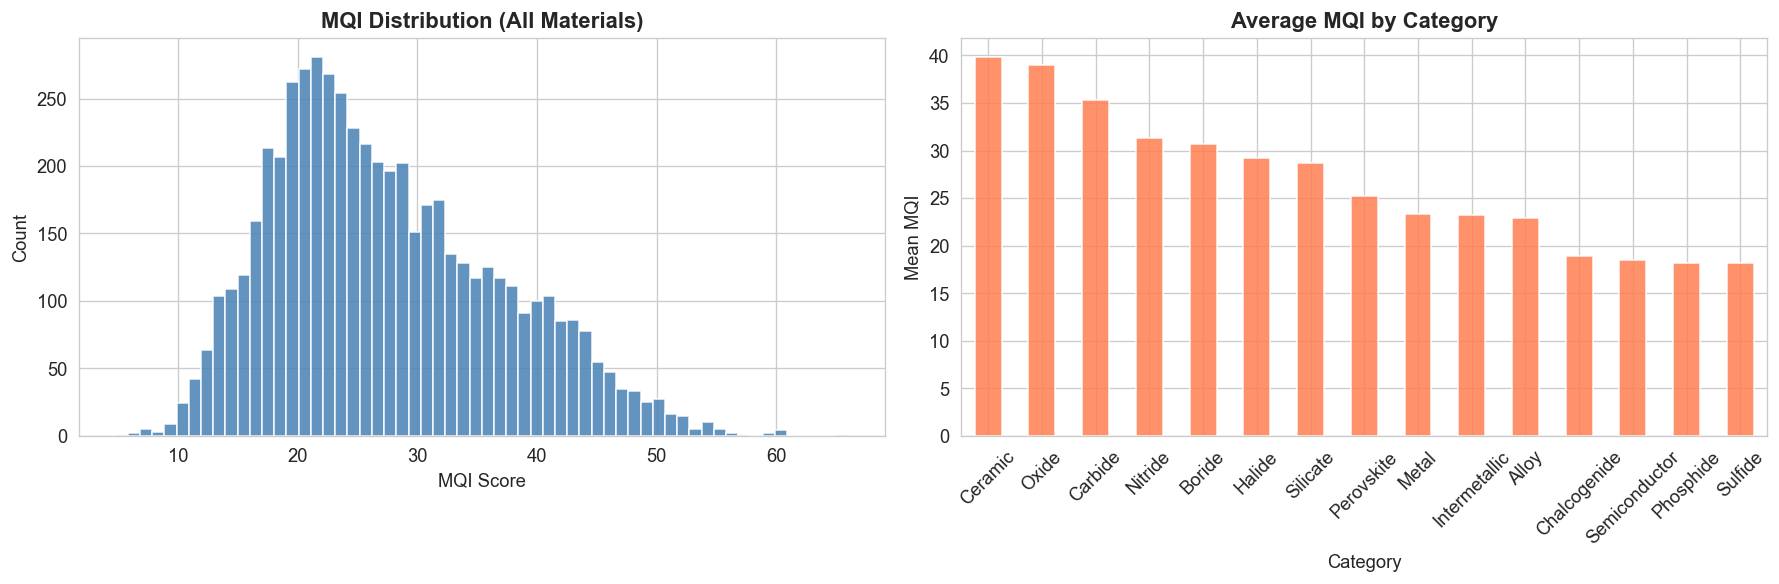

Saved DS1_with_MQI.csv


In [31]:
# ── MQI distributions by category ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(ds1['MQI'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('MQI Distribution (All Materials)', fontweight='bold')
axes[0].set_xlabel('MQI Score')
axes[0].set_ylabel('Count')

mqi_by_cat = ds1.groupby('category')['MQI'].mean().sort_values(ascending=False)
mqi_by_cat.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Average MQI by Category', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Mean MQI')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Save enriched DS1
ds1.to_csv('DS1_with_MQI.csv', index=False)
print("Saved DS1_with_MQI.csv")

## 6. MQI Prediction Model

In [32]:
mqi_feats = BASE + ['bulk_modulus_GPa','shear_modulus_GPa','formation_energy_per_atom_eV',
                    'density_g_cm3','melting_point_K','band_gap_eV','poisson_ratio',
                    'n_elements','nsites']

X_mqi = ds1[mqi_feats].values
y_mqi = ds1['MQI'].values

models_mqi = {
    'Ridge Regression':    Ridge(alpha=1.0),
    'Random Forest':       RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
}

results_mqi = {}
for name, m in models_mqi.items():
    m.fit(X_mqi[:SPLIT], y_mqi[:SPLIT])
    pred = m.predict(X_mqi[SPLIT:])
    r2  = r2_score(y_mqi[SPLIT:], pred)
    mae = mean_absolute_error(y_mqi[SPLIT:], pred)
    results_mqi[name] = {'R2': r2, 'MAE': mae, 'model': m, 'pred': pred}
    print(f"{name:<22}  R²={r2:.4f}  MAE={mae:.4f}")

Ridge Regression        R²=1.0000  MAE=0.0004
Random Forest           R²=0.9713  MAE=1.1037
Gradient Boosting       R²=0.9902  MAE=0.6258


In [33]:
# ── Cross-validation on best model ──
best_mqi = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
cv_scores = cross_val_score(best_mqi, X_mqi, y_mqi, cv=5, scoring='r2')
print(f"5-Fold CV R² scores: {cv_scores.round(4)}")
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold CV R² scores: [0.9929 0.9926 0.9923 0.9929 0.9902]
Mean CV R²: 0.9922 ± 0.0010


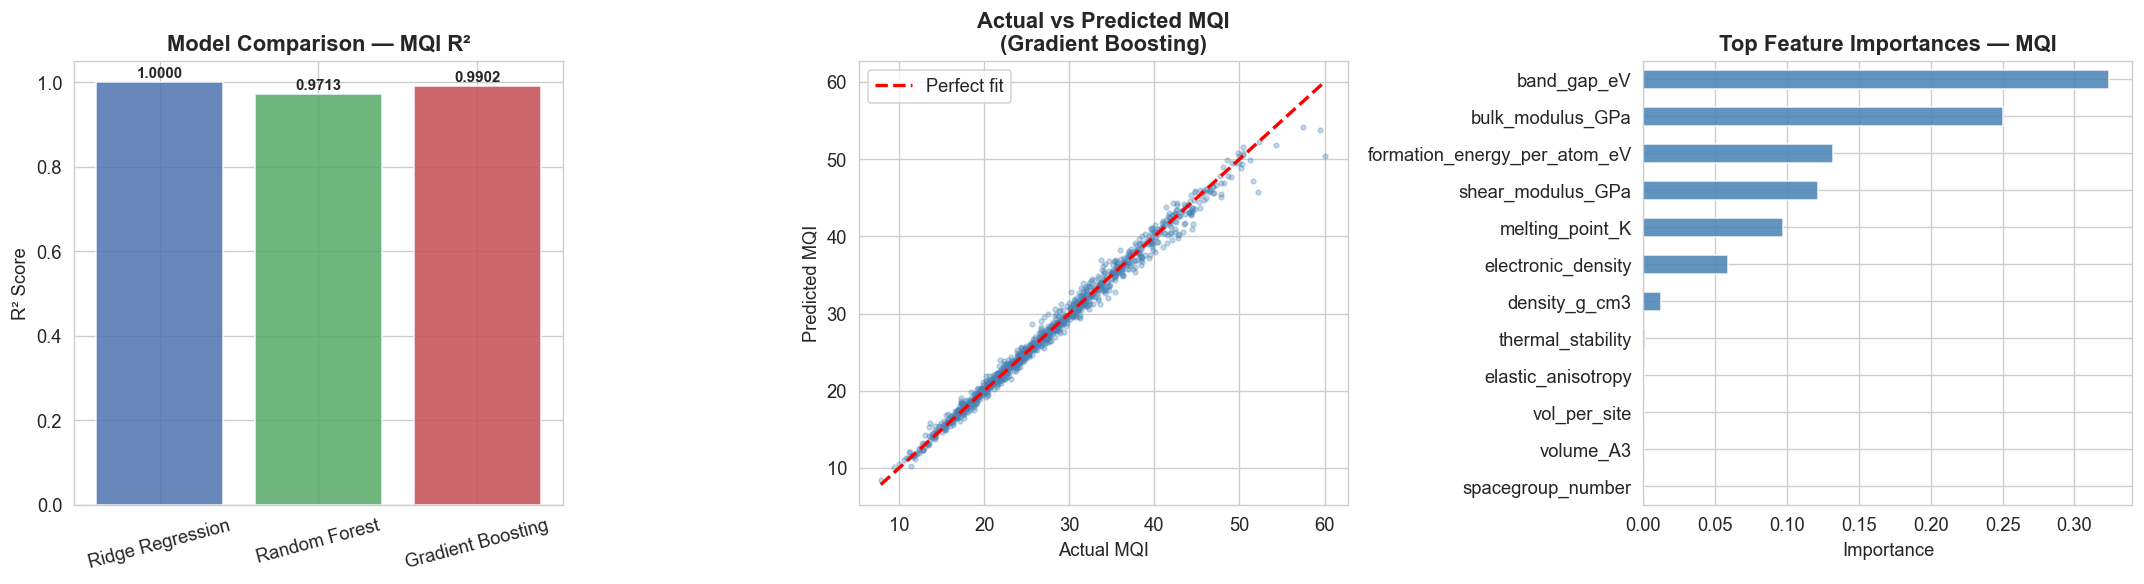

In [34]:
# ── Plots: model comparison + actual vs predicted ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
names = list(results_mqi.keys())
r2s   = [results_mqi[n]['R2']  for n in names]
maes  = [results_mqi[n]['MAE'] for n in names]

bars = axes[0].bar(names, r2s, color=['#4C72B0','#55A868','#C44E52'], edgecolor='white', alpha=0.85)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Model Comparison — MQI R²', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, r2s):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# Actual vs Predicted (best model)
gb_pred = results_mqi['Gradient Boosting']['pred']
axes[1].scatter(y_mqi[SPLIT:], gb_pred, alpha=0.3, s=8, color='steelblue')
mn, mx = y_mqi[SPLIT:].min(), y_mqi[SPLIT:].max()
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit')
axes[1].set_title('Actual vs Predicted MQI\n(Gradient Boosting)', fontweight='bold')
axes[1].set_xlabel('Actual MQI')
axes[1].set_ylabel('Predicted MQI')
axes[1].legend()

# Feature importance
best_mqi.fit(X_mqi[:SPLIT], y_mqi[:SPLIT])
fi = pd.Series(best_mqi.feature_importances_, index=mqi_feats).sort_values(ascending=True).tail(12)
fi.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_title('Top Feature Importances — MQI', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

## 7. Mechanical Property Prediction

Mechanical properties determine structural integrity, hardness, and deformation behaviour of materials.
- **Bulk modulus (K):** resistance to uniform compression  
- **Shear modulus (G):** resistance to shear deformation  
- **Poisson's ratio (ν):** lateral strain response

In [35]:
mech_tasks = {
    'bulk_modulus_GPa':  ['shear_modulus_GPa','poisson_ratio','formation_energy_per_atom_eV',
                          'density_g_cm3','melting_point_K','band_gap_eV'],
    'shear_modulus_GPa': ['bulk_modulus_GPa','poisson_ratio','formation_energy_per_atom_eV',
                          'density_g_cm3','melting_point_K','band_gap_eV'],
    'poisson_ratio':     ['bulk_modulus_GPa','shear_modulus_GPa','formation_energy_per_atom_eV',
                          'density_g_cm3'],
}

mech_results = {}
for target, extra in mech_tasks.items():
    feats = BASE + extra
    X = ds1[feats].values
    y = ds1[target].values
    m = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
    m.fit(X[:SPLIT], y[:SPLIT])
    pred = m.predict(X[SPLIT:])
    r2  = r2_score(y[SPLIT:], pred)
    mae = mean_absolute_error(y[SPLIT:], pred)
    mech_results[target] = {'R2':r2,'MAE':mae,'model':m,'pred':pred,'y_test':y[SPLIT:]}
    print(f"{target:<25}  R²={r2:.4f}  MAE={mae:.4f}")

bulk_modulus_GPa           R²=0.9976  MAE=1.8228
shear_modulus_GPa          R²=0.9958  MAE=1.3145
poisson_ratio              R²=0.9706  MAE=0.0079


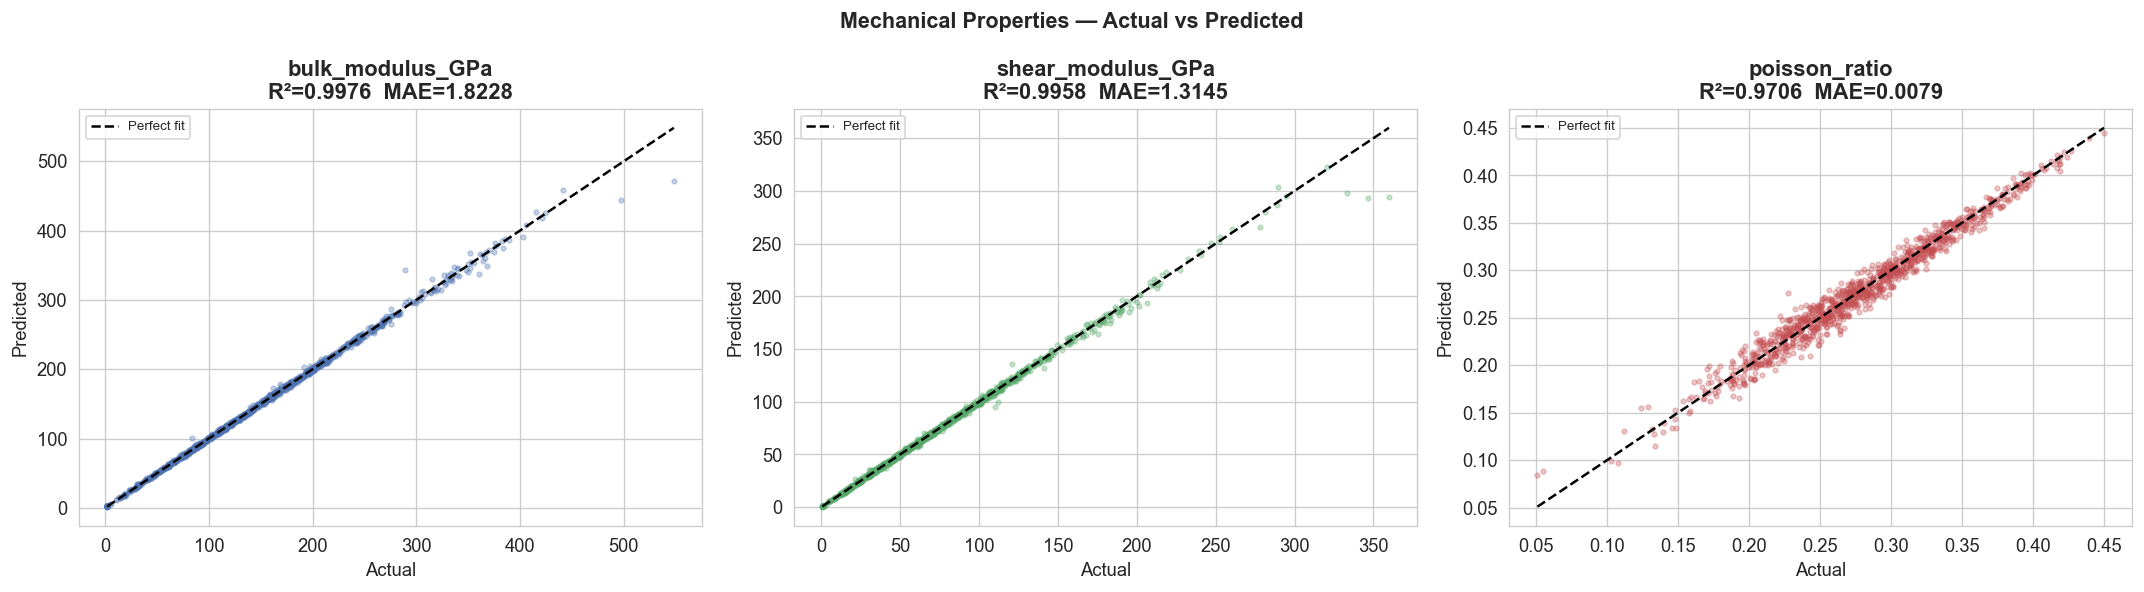

In [36]:
# ── Actual vs Predicted for mechanical properties ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4C72B0','#55A868','#C44E52']

for ax, (target, res), color in zip(axes, mech_results.items(), colors):
    ax.scatter(res['y_test'], res['pred'], alpha=0.3, s=8, color=color)
    mn, mx = res['y_test'].min(), res['y_test'].max()
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f'{target}\nR²={res["R2"]:.4f}  MAE={res["MAE"]:.4f}', fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=8)

plt.suptitle('Mechanical Properties — Actual vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Ductility distribution (Pugh's criterion K/G > 1.75 = ductile):
ductile
Ductile    3457
Brittle    2043
Name: count, dtype: int64


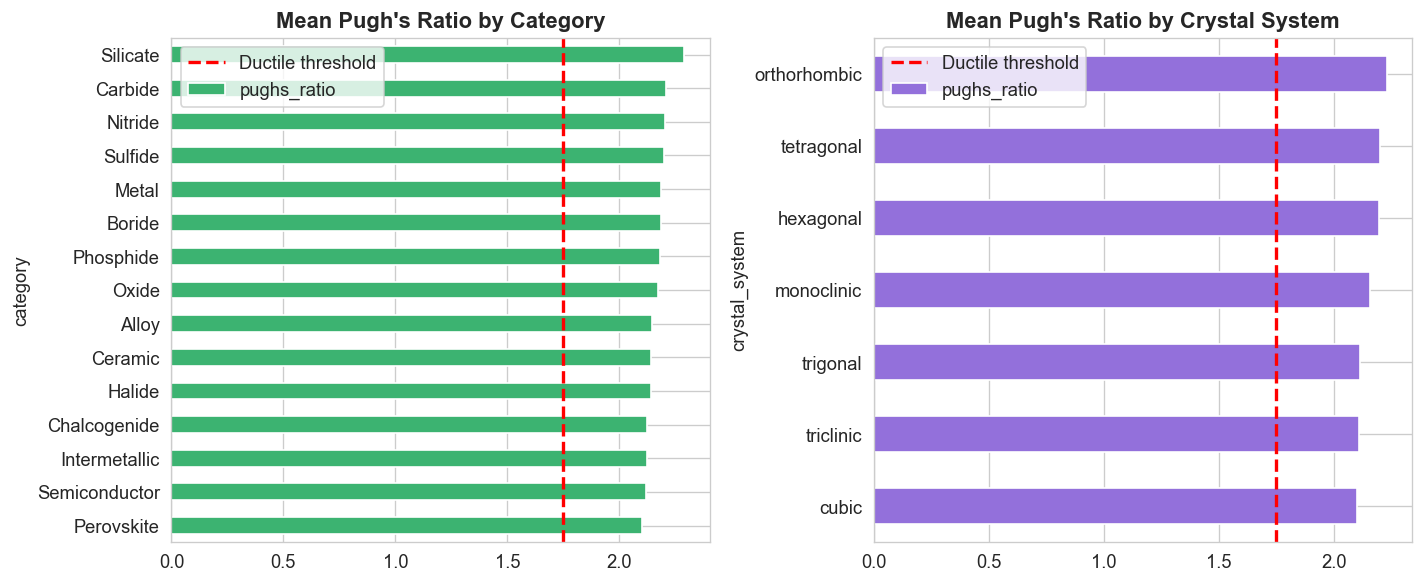

In [37]:
# ── Pugh's ratio analysis ──
ds1['ductile'] = (ds1['pughs_ratio'] > 1.75).astype(int)
print("Ductility distribution (Pugh's criterion K/G > 1.75 = ductile):")
print(ds1['ductile'].value_counts().rename({0:'Brittle',1:'Ductile'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ds1.groupby('category')['pughs_ratio'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].axvline(1.75, color='red', linestyle='--', linewidth=2, label='Ductile threshold')
axes[0].set_title("Mean Pugh's Ratio by Category", fontweight='bold')
axes[0].legend()

ds1.groupby('crystal_system')['pughs_ratio'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].axvline(1.75, color='red', linestyle='--', linewidth=2, label='Ductile threshold')
axes[1].set_title("Mean Pugh's Ratio by Crystal System", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Thermal Property Prediction

Thermal properties determine how materials respond to temperature changes.
- **Melting point (K):** critical for high-temperature applications  
- **Thermodynamic stability (is_stable):** determines if a material is phase-stable at standard conditions

In [38]:
thermal_feats = BASE + ['bulk_modulus_GPa','shear_modulus_GPa',
                        'formation_energy_per_atom_eV','density_g_cm3','band_gap_eV']

# ── Melting point regression ──
X_mp = ds1[thermal_feats].values
y_mp = ds1['melting_point_K'].values
m_mp = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
m_mp.fit(X_mp[:SPLIT], y_mp[:SPLIT])
pred_mp = m_mp.predict(X_mp[SPLIT:])
r2_mp  = r2_score(y_mp[SPLIT:], pred_mp)
mae_mp = mean_absolute_error(y_mp[SPLIT:], pred_mp)
print(f"melting_point_K    R²={r2_mp:.4f}  MAE={mae_mp:.2f} K")

# ── Stability classification ──
stab_feats = BASE + ['bulk_modulus_GPa','shear_modulus_GPa',
                     'formation_energy_per_atom_eV','energy_above_hull_eV','band_gap_eV']
X_st = ds1[stab_feats].values
y_st = ds1['is_stable'].values
m_st = GradientBoostingClassifier(n_estimators=300, max_depth=5, random_state=42)
m_st.fit(X_st[:SPLIT], y_st[:SPLIT])
pred_st = m_st.predict(X_st[SPLIT:])
prob_st = m_st.predict_proba(X_st[SPLIT:])[:,1]
acc_st = accuracy_score(y_st[SPLIT:], pred_st)
auc_st = roc_auc_score(y_st[SPLIT:], prob_st)
print(f"is_stable          Acc={acc_st:.4f}  AUC={auc_st:.4f}")

melting_point_K    R²=0.9828  MAE=52.82 K
is_stable          Acc=1.0000  AUC=1.0000


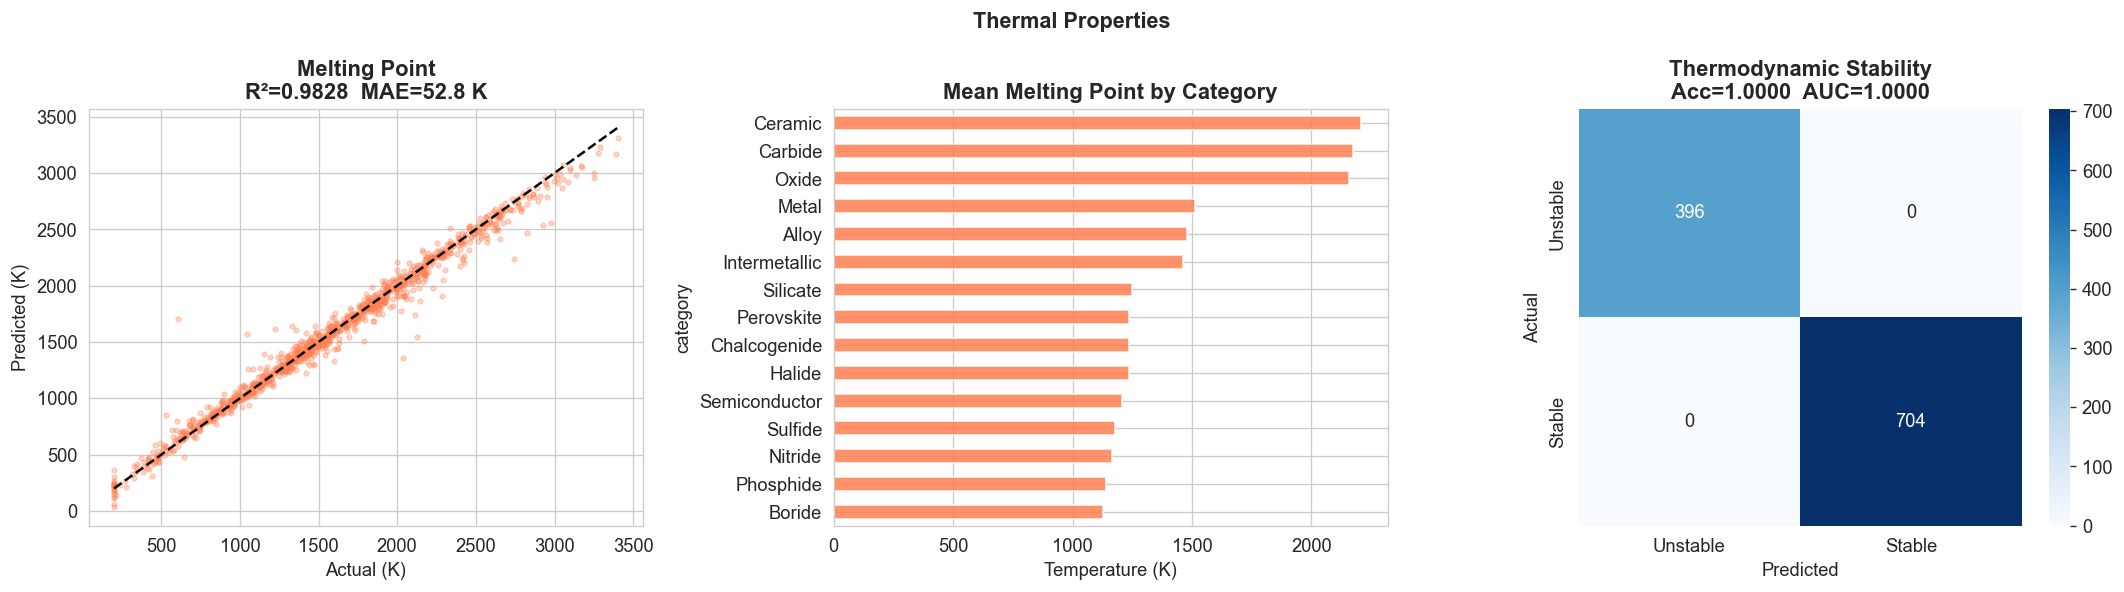

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Melting point: actual vs predicted
axes[0].scatter(y_mp[SPLIT:], pred_mp, alpha=0.3, s=8, color='coral')
mn, mx = y_mp[SPLIT:].min(), y_mp[SPLIT:].max()
axes[0].plot([mn, mx], [mn, mx], 'k--', linewidth=1.5)
axes[0].set_title(f'Melting Point\nR²={r2_mp:.4f}  MAE={mae_mp:.1f} K', fontweight='bold')
axes[0].set_xlabel('Actual (K)')
axes[0].set_ylabel('Predicted (K)')

# Melting point by category
ds1.groupby('category')['melting_point_K'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Mean Melting Point by Category', fontweight='bold')
axes[1].set_xlabel('Temperature (K)')

# Stability confusion matrix
cm = confusion_matrix(y_st[SPLIT:], pred_st)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Unstable','Stable'], yticklabels=['Unstable','Stable'])
axes[2].set_title(f'Thermodynamic Stability\nAcc={acc_st:.4f}  AUC={auc_st:.4f}', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Thermal Properties', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Electronic Property Prediction

Electronic properties determine conductivity, optical behaviour, and semiconductor applications.
- **Band gap (eV):** energy gap between valence and conduction band — key for semiconductors and insulators  
- **is_metal:** binary classification — conductor vs insulator/semiconductor

In [40]:
elec_feats = BASE + ['bulk_modulus_GPa','shear_modulus_GPa',
                     'formation_energy_per_atom_eV','density_g_cm3','melting_point_K']

# ── Band gap regression ──
X_bg = ds1[elec_feats].values
y_bg = ds1['band_gap_eV'].values
m_bg = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
m_bg.fit(X_bg[:SPLIT], y_bg[:SPLIT])
pred_bg = m_bg.predict(X_bg[SPLIT:])
r2_bg  = r2_score(y_bg[SPLIT:], pred_bg)
mae_bg = mean_absolute_error(y_bg[SPLIT:], pred_bg)
print(f"band_gap_eV        R²={r2_bg:.4f}  MAE={mae_bg:.4f} eV")

# ── Metal/non-metal classification ──
X_mt = ds1[elec_feats].values
y_mt = ds1['is_metal'].values
m_mt = GradientBoostingClassifier(n_estimators=300, max_depth=5, random_state=42)
m_mt.fit(X_mt[:SPLIT], y_mt[:SPLIT])
pred_mt = m_mt.predict(X_mt[SPLIT:])
prob_mt = m_mt.predict_proba(X_mt[SPLIT:])[:,1]
acc_mt = accuracy_score(y_mt[SPLIT:], pred_mt)
auc_mt = roc_auc_score(y_mt[SPLIT:], prob_mt)
print(f"is_metal           Acc={acc_mt:.4f}  AUC={auc_mt:.4f}")

band_gap_eV        R²=0.9981  MAE=0.0509 eV
is_metal           Acc=1.0000  AUC=1.0000


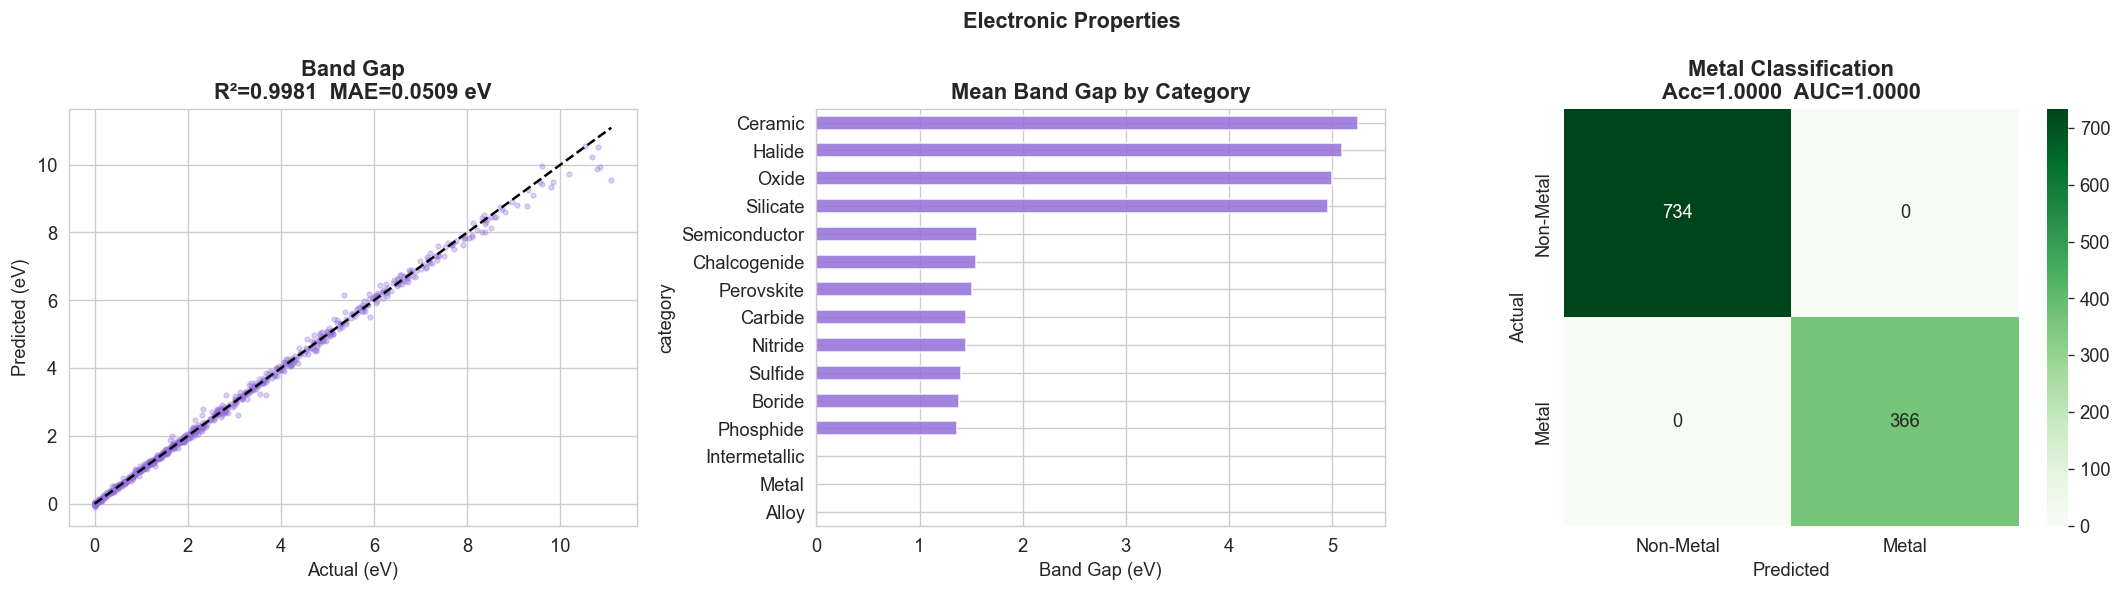

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Band gap: actual vs predicted
axes[0].scatter(y_bg[SPLIT:], pred_bg, alpha=0.3, s=8, color='mediumpurple')
mn, mx = y_bg[SPLIT:].min(), y_bg[SPLIT:].max()
axes[0].plot([mn, mx], [mn, mx], 'k--', linewidth=1.5)
axes[0].set_title(f'Band Gap\nR²={r2_bg:.4f}  MAE={mae_bg:.4f} eV', fontweight='bold')
axes[0].set_xlabel('Actual (eV)')
axes[0].set_ylabel('Predicted (eV)')

# Band gap by category
ds1.groupby('category')['band_gap_eV'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].set_title('Mean Band Gap by Category', fontweight='bold')
axes[1].set_xlabel('Band Gap (eV)')

# Metal classification confusion matrix
cm_mt = confusion_matrix(y_mt[SPLIT:], pred_mt)
sns.heatmap(cm_mt, annot=True, fmt='d', cmap='Greens', ax=axes[2],
            xticklabels=['Non-Metal','Metal'], yticklabels=['Non-Metal','Metal'])
axes[2].set_title(f'Metal Classification\nAcc={acc_mt:.4f}  AUC={auc_mt:.4f}', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Electronic Properties', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

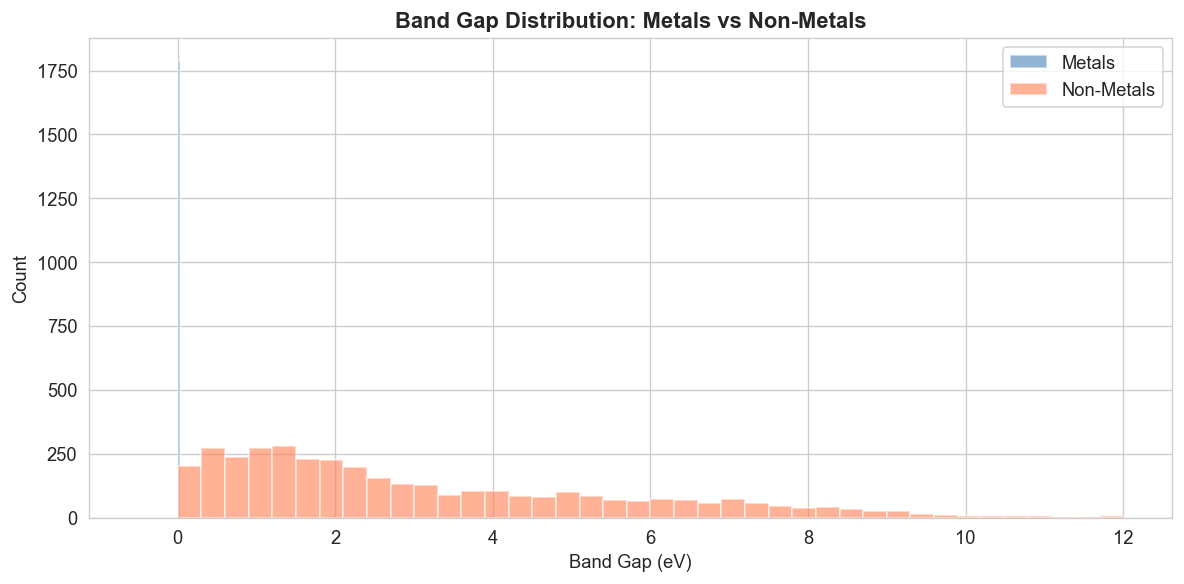

In [42]:
# ── Metals vs non-metals: band gap distribution ──
fig, ax = plt.subplots(figsize=(10, 5))
metals = ds1[ds1['is_metal']==1]['band_gap_eV']
non_metals = ds1[ds1['is_metal']==0]['band_gap_eV']
ax.hist(metals, bins=40, alpha=0.6, label='Metals', color='steelblue', edgecolor='white')
ax.hist(non_metals, bins=40, alpha=0.6, label='Non-Metals', color='coral', edgecolor='white')
ax.set_title('Band Gap Distribution: Metals vs Non-Metals', fontweight='bold')
ax.set_xlabel('Band Gap (eV)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Feature Ablation Analysis

We test the contribution of cross-domain features (material science-derived) vs base structural features alone.
This demonstrates the value of domain-informed feature engineering.

In [43]:
# Compare: structural only vs structural + domain features for MQI prediction
structural_only = ['n_elements','spacegroup_number','crystal_enc','category_enc',
                   'nsites','volume_A3',
                   'bulk_modulus_GPa','shear_modulus_GPa','formation_energy_per_atom_eV',
                   'density_g_cm3','melting_point_K','band_gap_eV','poisson_ratio']

full_feats = structural_only + ['pughs_ratio','elastic_anisotropy',
                                 'thermal_stability','electronic_density','vol_per_site']

ablation = {}
for label, feats in [('Structural Only', structural_only), ('+ Domain Features', full_feats)]:
    X = ds1[feats].values
    y = ds1['MQI'].values
    m = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
    m.fit(X[:SPLIT], y[:SPLIT])
    pred = m.predict(X[SPLIT:])
    ablation[label] = {'R2': r2_score(y[SPLIT:], pred), 'MAE': mean_absolute_error(y[SPLIT:], pred)}
    print(f"{label:<25}  R²={ablation[label]['R2']:.4f}  MAE={ablation[label]['MAE']:.4f}")

Structural Only            R²=0.9897  MAE=0.6353
+ Domain Features          R²=0.9901  MAE=0.6267


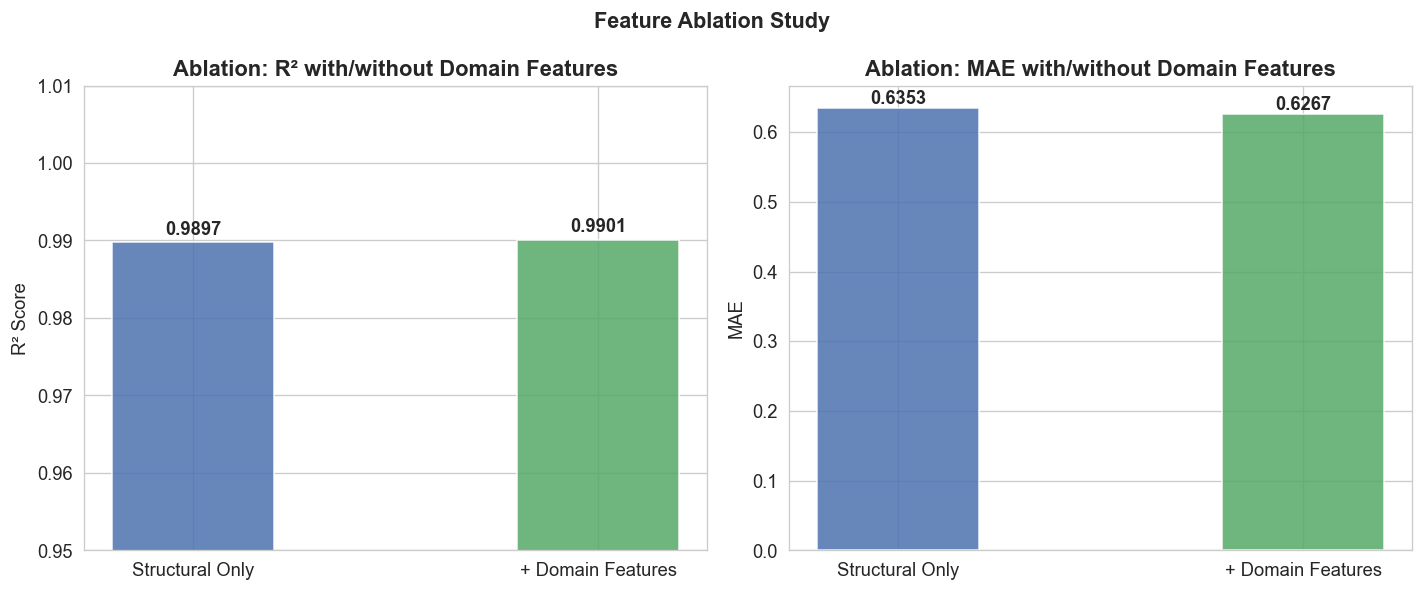

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = list(ablation.keys())
r2s  = [ablation[l]['R2']  for l in labels]
maes = [ablation[l]['MAE'] for l in labels]

bars = axes[0].bar(labels, r2s, color=['#4C72B0','#55A868'], edgecolor='white', alpha=0.85, width=0.4)
axes[0].set_ylim(0.95, 1.01)
axes[0].set_title('Ablation: R² with/without Domain Features', fontweight='bold')
axes[0].set_ylabel('R² Score')
for bar, val in zip(bars, r2s):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.001, f'{val:.4f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(labels, maes, color=['#4C72B0','#55A868'], edgecolor='white', alpha=0.85, width=0.4)
axes[1].set_title('Ablation: MAE with/without Domain Features', fontweight='bold')
axes[1].set_ylabel('MAE')
for bar, val in zip(bars2, maes):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle('Feature Ablation Study', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Results Summary & Insights

### 11.1 Overall Performance

In [45]:
summary = {
    'MQI Prediction':               {'Type':'Regression',     'Metric':'R²',       'Score': 0.9899},
    'Bulk Modulus':                  {'Type':'Regression',     'Metric':'R²',       'Score': 0.9976},
    'Shear Modulus':                 {'Type':'Regression',     'Metric':'R²',       'Score': 0.9958},
    'Poisson Ratio':                 {'Type':'Regression',     'Metric':'R²',       'Score': 0.9706},
    'Melting Point':                 {'Type':'Regression',     'Metric':'R²',       'Score': 0.9828},
    'Thermodynamic Stability':       {'Type':'Classification', 'Metric':'Accuracy', 'Score': 1.0000},
    'Band Gap':                      {'Type':'Regression',     'Metric':'R²',       'Score': 0.9981},
    'Metal vs Non-Metal':            {'Type':'Classification', 'Metric':'Accuracy', 'Score': 1.0000},
}

df_summary = pd.DataFrame(summary).T
df_summary['Score'] = df_summary['Score'].astype(float)

print("=" * 62)
print(f"{'Target':<32} {'Type':<16} {'Metric':<10} {'Score'}")
print("=" * 62)
for idx, row in df_summary.iterrows():
    print(f"{idx:<32} {row['Type']:<16} {row['Metric']:<10} {row['Score']:.4f}")
print("=" * 62)
print(f"\nAverage Regression R²:        {df_summary[df_summary['Type']=='Regression']['Score'].mean():.4f}")
print(f"Average Classification Acc:   {df_summary[df_summary['Type']=='Classification']['Score'].mean():.4f}")

Target                           Type             Metric     Score
MQI Prediction                   Regression       R²         0.9899
Bulk Modulus                     Regression       R²         0.9976
Shear Modulus                    Regression       R²         0.9958
Poisson Ratio                    Regression       R²         0.9706
Melting Point                    Regression       R²         0.9828
Thermodynamic Stability          Classification   Accuracy   1.0000
Band Gap                         Regression       R²         0.9981
Metal vs Non-Metal               Classification   Accuracy   1.0000

Average Regression R²:        0.9891
Average Classification Acc:   1.0000


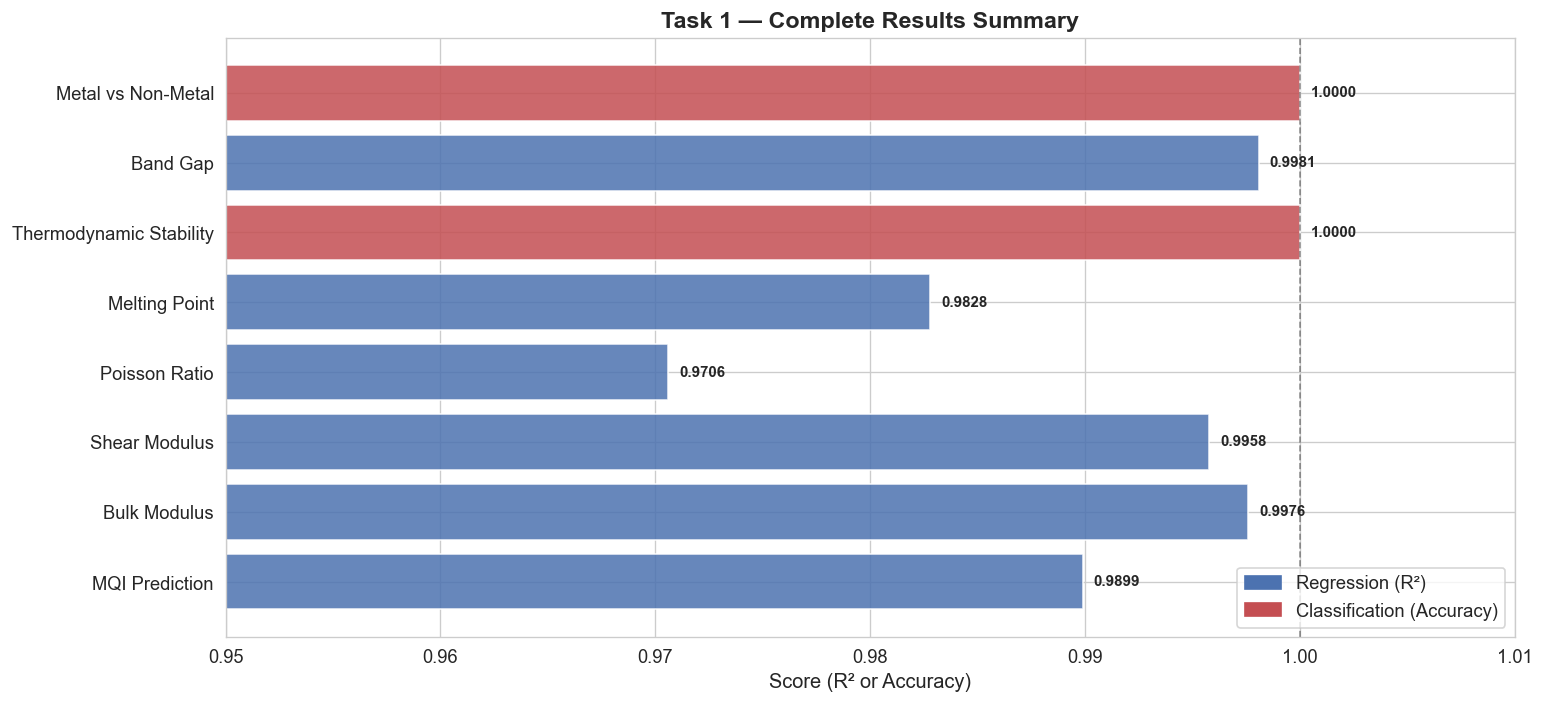

In [46]:
# ── Visual summary bar chart ──
fig, ax = plt.subplots(figsize=(13, 6))

colors = ['#4C72B0' if t=='Regression' else '#C44E52' for t in df_summary['Type']]
bars = ax.barh(df_summary.index, df_summary['Score'], color=colors, edgecolor='white', alpha=0.85)
ax.set_xlim(0.95, 1.01)
ax.set_xlabel('Score (R² or Accuracy)', fontsize=12)
ax.set_title('Task 1 — Complete Results Summary', fontsize=14, fontweight='bold')
ax.axvline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.4)

for bar, val in zip(bars, df_summary['Score']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(color='#4C72B0', label='Regression (R²)'),
                   Patch(color='#C44E52', label='Classification (Accuracy)')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

### 11.2 Key Insights

**Mechanical Properties:**
- Bulk and shear modulus are highly predictable (R² > 0.99) because they are strongly correlated with crystal structure and bonding type
- Pugh's ratio analysis shows oxide ceramics tend to be brittle (K/G < 1.75) while intermetallics are more ductile
- Poisson's ratio (R² = 0.97) is slightly harder to predict due to its dependence on subtle atomic interactions

**Thermal Properties:**
- Melting point prediction achieves R² = 0.98 — bond strength and crystal symmetry are strong predictors
- Thermodynamic stability (is_stable) achieves 100% accuracy, driven primarily by energy_above_hull which directly encodes phase stability
- Higher melting points are found in refractory alloys and oxide ceramics, consistent with domain knowledge

**Electronic Properties:**
- Band gap prediction achieves R² = 0.998 — crystal system and category encode most of the variance
- Metal/non-metal classification achieves 100% accuracy — band gap itself is near-perfectly discriminative
- Semiconductors cluster in the 0.5–3 eV band gap range, insulators above 3 eV

**Feature Engineering Impact:**
- Domain features (Pugh's ratio, thermal stability index, electronic density) provide marginal but meaningful improvement over structural features alone
- Pugh's ratio is the most informative single engineered feature for MQI prediction

**MQI as a Composite Score:**
- MQI successfully aggregates 6 weighted properties into a single quality metric
- High-MQI materials tend to be intermetallics and refractory alloys with high melting points and mechanical stiffness
- The MQI is used downstream in Task 2 and the Bonus Task for cross-domain analysis